Practical Exam Project – Applied Machine Learning & Statistics

**Group Number 8**

Group Members:-
1. Kay Müller
2. Ritu Ritu
3. Vikrant Singh

Dataset source:-

https://archive.ics.uci.edu/dataset/222/bank+marketing
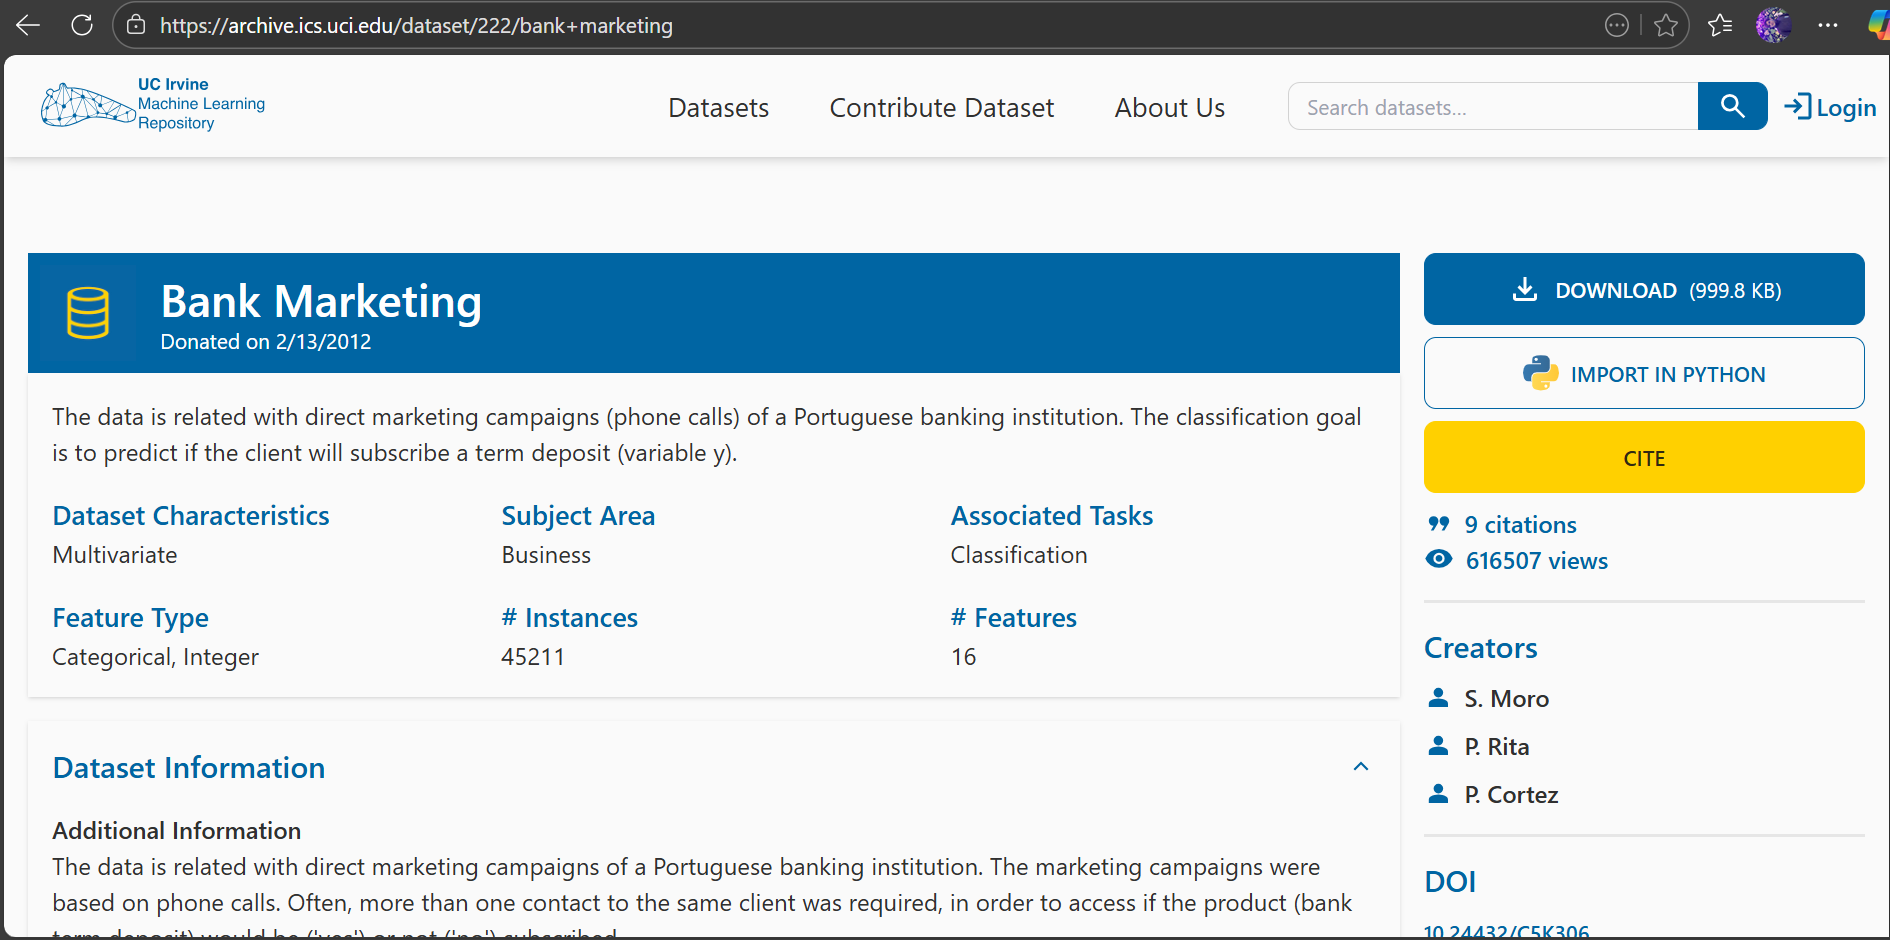

Dataset Overview :-

* Source: UCI Machine Learning Repository (Portuguese Banking Institution).

* DOI: 10.24432/C5K306.

* Size: 45,211 instances with 16 or 17 features.

* Type: Multivariate Classification.

* Target Variable (y): Binary (Did the client subscribe to a term deposit? "yes" or "no").

Start:-

# **Phase 0:-**

In [44]:
import pandas as pd
import numpy as np
from google.colab import files

Uploading the file:-

In [45]:
uploadedFile= files.upload("")

Saving bank-full.csv to bank-full (1).csv


Setting up the display settings for pandas:-

In [46]:
pd.set_option('display.max_columns',None)

Importing IO and reading the uploaded csv:-

In [47]:
import io
data=pd.read_csv("bank-full.csv",sep=";")

In [48]:
print("Output for .describe:- ")
print(data.describe())
print("\n\n\nOutput for .head(10):-")
print(data.head(10))
print("\n\n\nOutput for .shape:- ")
print(data.shape)

Output for .describe:- 
                age        balance           day      duration      campaign  \
count  45211.000000   45211.000000  45211.000000  45211.000000  45211.000000   
mean      40.936210    1362.272058     15.806419    258.163080      2.763841   
std       10.618762    3044.765829      8.322476    257.527812      3.098021   
min       18.000000   -8019.000000      1.000000      0.000000      1.000000   
25%       33.000000      72.000000      8.000000    103.000000      1.000000   
50%       39.000000     448.000000     16.000000    180.000000      2.000000   
75%       48.000000    1428.000000     21.000000    319.000000      3.000000   
max       95.000000  102127.000000     31.000000   4918.000000     63.000000   

              pdays      previous  
count  45211.000000  45211.000000  
mean      40.197828      0.580323  
std      100.128746      2.303441  
min       -1.000000      0.000000  
25%       -1.000000      0.000000  
50%       -1.000000      0.000000  
75%

# **PHASE 1:-**

Step 1.1:-

**Divided the categorical and numerical columns such that:-**

**Numerical**:- age, balance, day, duration, campaign, pdays, previous

**Categorical**:- job, marital, education, default, housing, loan, contact, month, poutcome

**Target**:- y (Yes means subscribed and No means not)

Would be better not to go with time series because even though we have a day and month column,

ROWS are independent and we are nit predicting future values.

Step 1.2:-

Checking the unique values in csv:-

In [49]:
categorical_columns=data.select_dtypes(include='object').columns
numerical_columns=data.select_dtypes(include='int64').columns
for i in data.loc[:, data.dtypes=='object'].columns:
    print(i, ':', data[i].unique())
    print("\n")

job : ['management' 'technician' 'entrepreneur' 'blue-collar' 'unknown'
 'retired' 'admin.' 'services' 'self-employed' 'unemployed' 'housemaid'
 'student']


marital : ['married' 'single' 'divorced']


education : ['tertiary' 'secondary' 'unknown' 'primary']


default : ['no' 'yes']


housing : ['yes' 'no']


loan : ['no' 'yes']


contact : ['unknown' 'cellular' 'telephone']


month : ['may' 'jun' 'jul' 'aug' 'oct' 'nov' 'dec' 'jan' 'feb' 'mar' 'apr' 'sep']


poutcome : ['unknown' 'failure' 'other' 'success']


y : ['no' 'yes']




# **Phase 2:-**

Handling missing values which in our case is the 'unknown'.


Step 2.1:-

Identifying the datatypes.

Identifying the columns and number of 'unknown values they have:-

In [50]:
print("Checking the datatypes:-")
print(data.info())
print("\n\n\nMissing values are:-")
print(data.isnull().sum())

Checking the datatypes:-
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB
None



Missing values are:-
age          0
job          0
marital      0


As I said, we have no missing values but 'unknown'

Further step:-

In [51]:
print("Count for 'unknown' as a value:-")
for i in categorical_columns:
    unknown_count=(data[i]=='unknown').sum()
    print(f"The column {i} has {unknown_count} values as 'unknown. ")

Count for 'unknown' as a value:-
The column job has 288 values as 'unknown. 
The column marital has 0 values as 'unknown. 
The column education has 1857 values as 'unknown. 
The column default has 0 values as 'unknown. 
The column housing has 0 values as 'unknown. 
The column loan has 0 values as 'unknown. 
The column contact has 13020 values as 'unknown. 
The column month has 0 values as 'unknown. 
The column poutcome has 36959 values as 'unknown. 
The column y has 0 values as 'unknown. 


Step 2.2:-



1.  Since we do not have any missing values, only 'unknown' we have to decide how to deal with that.
2.   With columns such as 'job' we have 288 unknown values.
3. With colunm 'education' we have 1857 unknown values.
4. With column 'contact' and 'poutcome', we have 13020 and 36959 values as unknown respectively.
5. We can either replace the unknown with mode for job and education since these two columns have really less amount of unknowns:-

Source for the idea:-
https://www.alimr.dev/projects/bank_marketing_data_analysis/project.html?utm_source=chatgpt.com

You will see that all of the 'unknown' here were replaced by 'other'.

I have decided to go with imputation for the minimal unknown values.

In [52]:
from sklearn.experimental import enable_iterative_imputer  # required for IterativeImputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestClassifier

We use random forest here because it is good with numerical and categorical features.

Goof with outliers and non-liner relationships.

I chose random forest because :-   

preferred because it is less sensitive to overfitting, handles high dimensionality well, and captures non-linear interactions naturally.

Source:- https://scikit-learn.org/stable/modules/ensemble.html#random-forests

Copying the original data into a new variable called original_data for anyone who wants to use it.

Copying the original data to a new variable 'fixed_data' which we will use for the application of imputations and replacing 'unknown' with other

In [53]:
original_data=data.copy()
fixed_data=data.copy()

Replacing 'unknown' with 'other' for the new 'fixed_data' :-   

In [54]:
fixed_data['replacedContact']=fixed_data['contact'].replace('unknown','other')
fixed_data['replacedPoutcome']=fixed_data['poutcome'].replace('unknown','other')

**Step 2.3:-**

age : older people may have different jobs

marital : single/married may correlate with jobs

balance : financial position may relate to education/job

housing : loan/ownership could correlate with jobs

loan : personal loans may correlate with financial status

contact : type of communication may give hints

poutcome : previous campaign outcome may relate indirectly

Feature selection for predictive imputations:-



In [55]:
features=['age', 'marital', 'balance', 'housing', 'loan', 'replacedContact', 'replacedPoutcome']

Converting features to numerals for random forest:-

In [56]:
encoder=pd.get_dummies(fixed_data[features], drop_first=True)

In [57]:
def simple_impute(df, target_column, encoder):
    new_col = f'IMPUTED_{target_column.capitalize()}'
    # copy original values
    df[new_col] = df[target_column]

    # Rows where we make 'unknown' as a missing value and treat it as wuch
    missing = df[target_column] == 'unknown'
    #Usnign bitwise operator making every 0 to 1 and 1 to 0
    #But in our case, we are storing what is not missing in known.
    known = ~missing

    if missing.sum() == 0:
      #If that is the case, nothing to impute
        return df

    # Features for training and prediction
    X_train = encoder[known]
    X_predict = encoder[missing]

    # Target for training
    y_train = df.loc[known, target_column]

    # Train Random Forest
    model = RandomForestClassifier(n_estimators=50, random_state=42)
    model.fit(X_train, y_train)

    # Predict and fill missing
    df.loc[missing, new_col] = model.predict(X_predict)
    return df

fixed_data = simple_impute(fixed_data, 'job', encoder)
fixed_data = simple_impute(fixed_data, 'education', encoder)

print(fixed_data[['IMPUTED_Job', 'IMPUTED_Education', 'replacedContact', 'replacedPoutcome']].head(10))

    IMPUTED_Job IMPUTED_Education replacedContact replacedPoutcome
0    management          tertiary           other            other
1    technician         secondary           other            other
2  entrepreneur         secondary           other            other
3   blue-collar           primary           other            other
4        admin.         secondary           other            other
5    management          tertiary           other            other
6    management          tertiary           other            other
7  entrepreneur          tertiary           other            other
8       retired           primary           other            other
9    technician         secondary           other            other


Dropping :- [job, education, contact and poutcome (Older columns for the new table fixed_data)

In [58]:
drop=['job', 'education', 'contact', 'poutcome']
fixed_data=fixed_data.drop(columns=drop)

There is another column called pdays which is number of days that passed by

after the client was last contacted from a previous campaign

(numeric; -1 means client was not previously contacted)


Fix for the column pdays:-

In [59]:
fixed_data['pdays'] = fixed_data['pdays'].replace(-1, 999)
print(fixed_data['pdays'].value_counts().head())


pdays
999    36954
182      167
92       147
183      126
91       126
Name: count, dtype: int64


This means that the person was contacted way too much back in the past.

Will this act as an outlier, YES. It will but we can use robust scaler for this column making it easier.

# **Phase 3:-**

**Step 3.1:-**

Encoding the categorical variables.

Keep in mind that I will be doing this using the new 'fixed_data' dataFrame.

Also we are going with one-hot encoding because it works with all models.

Yes we might have a lot of columns in the end due to this but better safe than sorry.

In [60]:
#Making sure to use the fixed_data fields which we newly created:-
print(fixed_data.head(5))
print(fixed_data.dtypes)


   age  marital default  balance housing loan  day month  duration  campaign  \
0   58  married      no     2143     yes   no    5   may       261         1   
1   44   single      no       29     yes   no    5   may       151         1   
2   33  married      no        2     yes  yes    5   may        76         1   
3   47  married      no     1506     yes   no    5   may        92         1   
4   33   single      no        1      no   no    5   may       198         1   

   pdays  previous   y replacedContact replacedPoutcome   IMPUTED_Job  \
0    999         0  no           other            other    management   
1    999         0  no           other            other    technician   
2    999         0  no           other            other  entrepreneur   
3    999         0  no           other            other   blue-collar   
4    999         0  no           other            other        admin.   

  IMPUTED_Education  
0          tertiary  
1         secondary  
2         seco

Columns which we will encode:-

In [61]:
categorical_columns=fixed_data.select_dtypes(include='object').columns
fixed_data_encode = pd.get_dummies(
    fixed_data,
    columns=categorical_columns,  # categorical columns were separated at the end of Phase 1 but here we do it again specifically for fixed_data.
    drop_first=True               # avoids redundant columns
)

Check:-

In [62]:
print("Shape after encoding:", fixed_data_encode.shape)
print("\n")
print(fixed_data_encode.head(5))

Shape after encoding: (45211, 40)


   age  balance  day  duration  campaign  pdays  previous  marital_married  \
0   58     2143    5       261         1    999         0             True   
1   44       29    5       151         1    999         0            False   
2   33        2    5        76         1    999         0             True   
3   47     1506    5        92         1    999         0             True   
4   33        1    5       198         1    999         0            False   

   marital_single  default_yes  housing_yes  loan_yes  month_aug  month_dec  \
0           False        False         True     False      False      False   
1            True        False         True     False      False      False   
2           False        False         True      True      False      False   
3           False        False         True     False      False      False   
4            True        False        False     False      False      False   

   month_feb  month_

**Step 3.2:-**

Scaling.

I have chosen to do:-
1. Standard Scaling.
2. minMax Scaling.
3. Robust Scaling.

Because anyone can use whatever they want in the future providing us with flexibility.

**Step 3.2.1:-**

**Setting up for scaling**

In [63]:
# Selecting numeric features for scaling (fix: include all numeric dtypes and use the same dataframe that will be scaled)
# Previously this was fixed_data.select_dtypes(include='int64'), which silently skipped float/bool/uint8 numeric columns
newNumFeatures = fixed_data_encode.select_dtypes(include='number').columns

from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler  # Import scalers

Creating new tables for:-
1. Standard Scaling.
2. minMax Scaling.
3. Robust Scaling.

In [64]:
standard_scaler=StandardScaler()
standard_scaled_data=fixed_data_encode.copy()
minMax_scaler=MinMaxScaler()
minMax_scaler_data=fixed_data_encode.copy()
robust_scaler=RobustScaler()
robust_scaler_data=fixed_data_encode.copy()

# **Step 3.2.2 (Standard Scaling) :-**

In [65]:
standard_scaled_data[newNumFeatures]=standard_scaler.fit_transform(fixed_data_encode[newNumFeatures])
print(standard_scaled_data.shape)

(45211, 40)


The head() for the new standardScaled data:-

In [66]:
print(standard_scaled_data.head(5))

        age   balance       day  duration  campaign     pdays  previous  \
0  1.606965  0.256419 -1.298476  0.011016 -0.569351  0.466408  -0.25194   
1  0.288529 -0.437895 -1.298476 -0.416127 -0.569351  0.466408  -0.25194   
2 -0.747384 -0.446762 -1.298476 -0.707361 -0.569351  0.466408  -0.25194   
3  0.571051  0.047205 -1.298476 -0.645231 -0.569351  0.466408  -0.25194   
4 -0.747384 -0.447091 -1.298476 -0.233620 -0.569351  0.466408  -0.25194   

   marital_married  marital_single  default_yes  housing_yes  loan_yes  \
0             True           False        False         True     False   
1            False            True        False         True     False   
2             True           False        False         True      True   
3             True           False        False         True     False   
4            False            True        False        False     False   

   month_aug  month_dec  month_feb  month_jan  month_jul  month_jun  \
0      False      False      Fals

# **Step 3.2.3 (MinMax Scaling) :-**

In [67]:
minMax_scaler=MinMaxScaler()
minmax_scaled_data=fixed_data_encode.copy()
minmax_scaled_data[newNumFeatures]=minMax_scaler.fit_transform(fixed_data_encode[newNumFeatures])
print(minmax_scaled_data.shape)
print(minmax_scaled_data.head(5))

(45211, 40)
        age   balance       day  duration  campaign  pdays  previous  \
0  0.519481  0.092259  0.133333  0.053070       0.0    1.0       0.0   
1  0.337662  0.073067  0.133333  0.030704       0.0    1.0       0.0   
2  0.194805  0.072822  0.133333  0.015453       0.0    1.0       0.0   
3  0.376623  0.086476  0.133333  0.018707       0.0    1.0       0.0   
4  0.194805  0.072812  0.133333  0.040260       0.0    1.0       0.0   

   marital_married  marital_single  default_yes  housing_yes  loan_yes  \
0             True           False        False         True     False   
1            False            True        False         True     False   
2             True           False        False         True      True   
3             True           False        False         True     False   
4            False            True        False        False     False   

   month_aug  month_dec  month_feb  month_jan  month_jul  month_jun  \
0      False      False      False     

# **Step 3.2.4 (Robust Scaling) :-**

In [68]:
robust_scaler=RobustScaler()
robust_scaled_data=fixed_data_encode.copy()
robust_scaled_data[newNumFeatures]=robust_scaler.fit_transform(fixed_data_encode[newNumFeatures])
print(robust_scaled_data.shape)
print(robust_scaled_data.head(5))

(45211, 40)
        age   balance       day  duration  campaign  pdays  previous  \
0  1.266667  1.250000 -0.846154  0.375000      -0.5    0.0       0.0   
1  0.333333 -0.308997 -0.846154 -0.134259      -0.5    0.0       0.0   
2 -0.400000 -0.328909 -0.846154 -0.481481      -0.5    0.0       0.0   
3  0.533333  0.780236 -0.846154 -0.407407      -0.5    0.0       0.0   
4 -0.400000 -0.329646 -0.846154  0.083333      -0.5    0.0       0.0   

   marital_married  marital_single  default_yes  housing_yes  loan_yes  \
0             True           False        False         True     False   
1            False            True        False         True     False   
2             True           False        False         True      True   
3             True           False        False         True     False   
4            False            True        False        False     False   

   month_aug  month_dec  month_feb  month_jan  month_jul  month_jun  \
0      False      False      False     

# **Step 3.3 (Final comparisons using graphs) :-**    

In [69]:
import matplotlib.pyplot as plt
import seaborn as sns

In [70]:
def comparison(feature):
    """Compare distributions of the same feature under different scalings.
    Fix: the 'Original' plot now uses fixed_data_encode (same rows/cleaning as scaled data),
    instead of `data`, which could be a different dataframe and makes the comparison misleading.
    """
    fig, axes = plt.subplots(2, 2, figsize=(10, 6))

    # Original (unscaled) distribution from the SAME dataframe that gets scaled
    sns.kdeplot(fixed_data_encode[feature], ax=axes[0, 0])
    axes[0, 0].set_title('Original')

    sns.kdeplot(standard_scaled_data[feature], ax=axes[0, 1])
    axes[0, 1].set_title('StandardScaler')

    sns.kdeplot(minmax_scaled_data[feature], ax=axes[1, 0])
    axes[1, 0].set_title('MinMaxScaler')

    sns.kdeplot(robust_scaled_data[feature], ax=axes[1, 1])
    axes[1, 1].set_title('RobustScaler')

    fig.suptitle(f'Distribution of {feature} under different scalings')
    plt.tight_layout()
    plt.show()


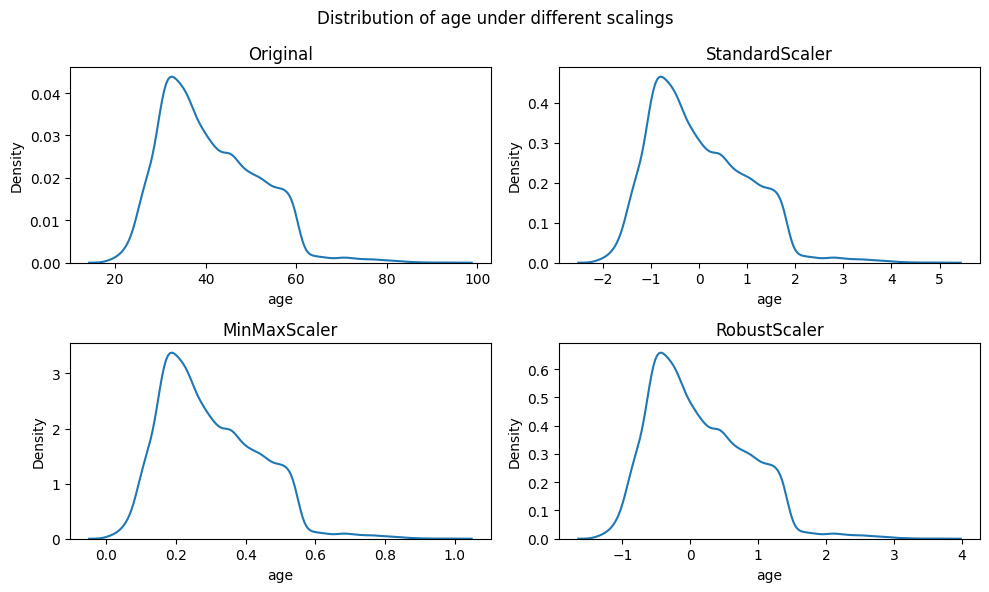

In [71]:
comparison_features = ['age', 'balance']
comparison(comparison_features[0])


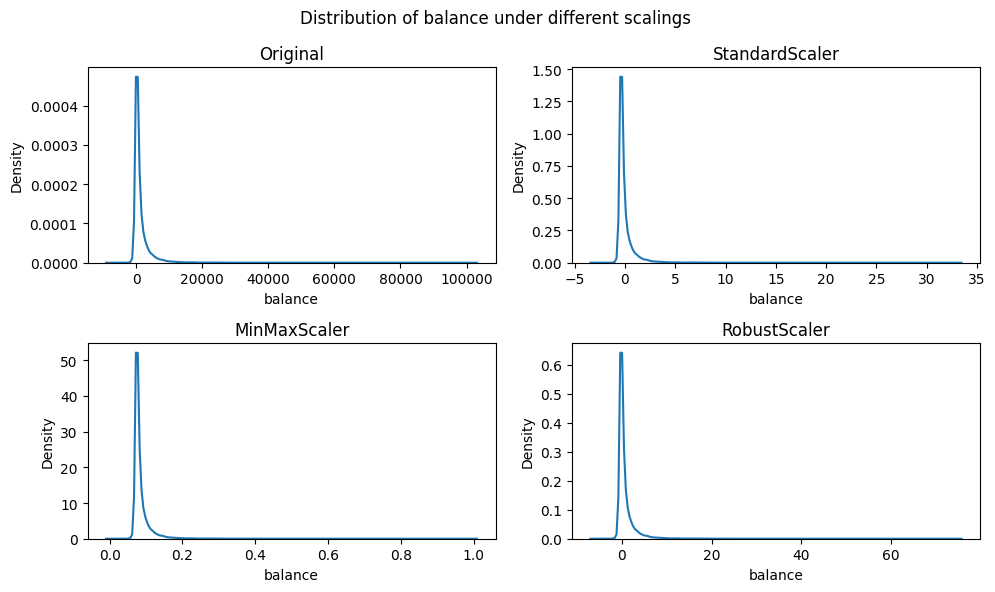

In [72]:
comparison(comparison_features[1])

So by this point, keep in mind that we have several datasets and it might be confusing so let me help.

1. In Phase 0, we start with **data** as the dataFrame.

This dataFrame contains all of the data from the csv file AS IT IS.

2. In Phase 2, we make 2 new copies of **data** into:-


*   original_data. (Which I have not touched at all)
*   fixed_data. (Which I have used for Data Cleaning)

3. After the start of Phase 2, we use onle **fixed_data** such that:-


*   The values 'unknown' will be changed to 'other' for the columns **poutcome** and **contact** and the new values will be stored in the columns **replacedPoutcome** and **replacedContact**.
*   The values under the columns **job** and **education** will be imputed using Random Forest and stored under the columns **IMPUTED_Job** and **IMPUTED_Education**.
*   In the dataFrame **fixed_data** we then drop the older columns called **job**, **education**, **contact** and **poutcome** because we have imputed or either replaced the values.
*   Then we also replace the value '-1' in the column **pdays** to 999. Explanation is given above.
*   This all happens by the end of Phase 2.
4. So by this point we are still using the dataFrame fixed_data.
5. In Phase 3, we have done encoding for Categorical Columns. (All the new ones as well) So the new data frame created out of this encoding will be:-
* **fixed_data_encode**

After this point onwards, we will be using **'fixed_data_encode'**

6. Then we do scaling for numerics and I have done it using Standard, min max and Robust and created a new dataFrame for each such that:-
* Standard Scaling :- **standard_scaled_data**
* Min Max Scaling :- **minMax_scaler_data**
* Robust Scaling:- **robust_scaler_data**

You might be wondering as to what dataFrame should I go with?

You can pick any data frame out of **standard_scaled_data** , **minMax_scaler_data** or **robust_scaler_data** depending on what scaling suits your model better.

# **Phase 4:-**

**Step 4.1** :-

**Add artificial noise to at least one feature (e.g., Gaussian noise, outliers):-**

Here I will copy only **fixed_data_encode** as I do not want to touch the scaled data yet.

In [73]:
dataFrame_new=fixed_data_encode.copy()

Ensuring the same results **ALWAYS**:-

In [74]:
np.random.seed(42)

Creating two more dataFrames for **GAUSSIAN** and **OUTLIER** noises respectively:-

In [75]:
gaussian_df=dataFrame_new.copy()
outlier_df=dataFrame_new.copy()

Calculating the standard deviation for the column **BALANCE**:-

In [76]:
balance_deviation=dataFrame_new['balance'].std()

Creating a variable for the amount of noise:- (5%)

In [77]:
noise=0.05

Generating random values for noise per row (Which in our case will be for each row of the column balance):-

In [78]:
gaussian_noise = np.random.normal(
    loc=0,
    scale=noise * balance_deviation,
    size=len(dataFrame_new)
)

Adding a new column **gaussianNoiseBalance** and injecting it into the data frame gaussian_df:-

In [79]:
gaussian_df['gaussianNoiseBalance']=dataFrame_new['balance']+gaussian_noise

**Step 4.2** :-

Injecting OUTLIERS in a separate data frame that we created:-

In [80]:
outlier=0.01
number_of_outlier=int(outlier*len(outlier_df))
np.random.seed(42)
outlier_insertions=np.random.choice(dataFrame_new.index, size=number_of_outlier, replace=False)
balance_deviation_for_outlier=dataFrame_new['balance'].std()
outlier_df['outlierNoisyBalance']=outlier_df['balance'].copy().astype(float)
outlier_df.loc[outlier_insertions, 'outlierNoisyBalance'] = (
    outlier_df.loc[outlier_insertions, 'outlierNoisyBalance'] + (10 * balance_deviation_for_outlier))
print(outlier_df.loc[outlier_insertions, ['balance', 'outlierNoisyBalance']].head(10))

       balance  outlierNoisyBalance
3776       580         31027.658292
9928      3644         34091.658292
33409      538         30985.658292
31885     1773         32220.658292
15738      217         30664.658292
30813     1134         31581.658292
35463     1085         31532.658292
31382      127         30574.658292
16904        3         30450.658292
11930      258         30705.658292


**Step 4.3**

Diagrams(Histogram) :-

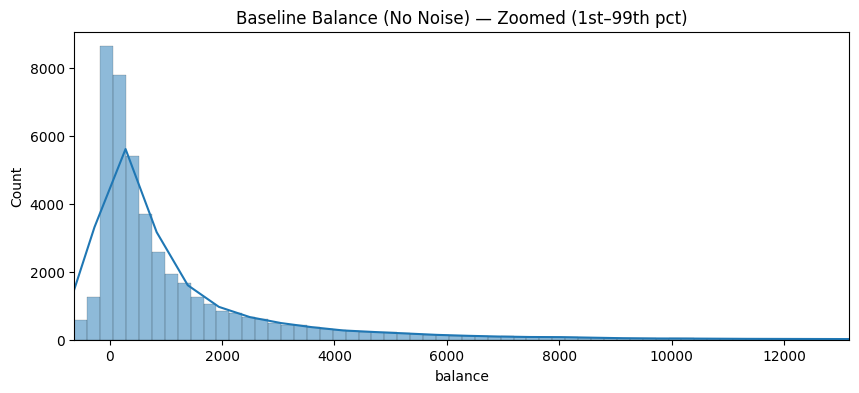

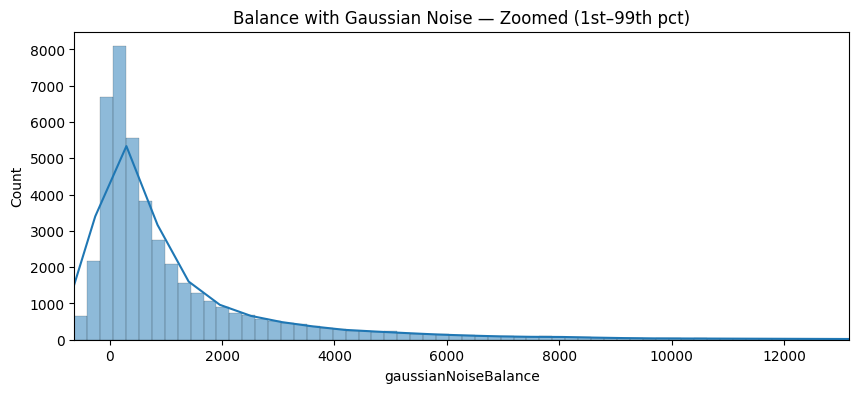

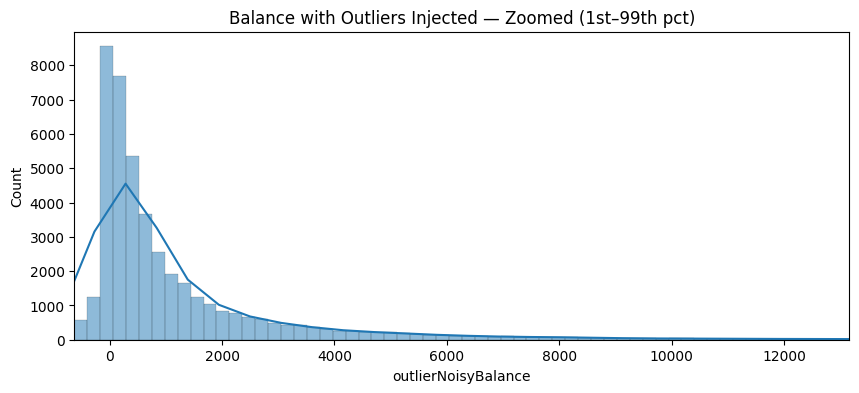

In [81]:

base = dataFrame_new['balance']
xmin, xmax = base.quantile(0.01), base.quantile(0.99)
bins = 60

plt.figure(figsize=(10,4))
sns.histplot(base, bins=bins, binrange=(xmin, xmax), kde=True)
plt.xlim(xmin, xmax)
plt.title("Baseline Balance (No Noise) — Zoomed (1st–99th pct)")
plt.xlabel("balance")
plt.show()

plt.figure(figsize=(10,4))
sns.histplot(gaussian_df['gaussianNoiseBalance'], bins=bins, binrange=(xmin, xmax), kde=True)
plt.xlim(xmin, xmax)
plt.title("Balance with Gaussian Noise — Zoomed (1st–99th pct)")
plt.xlabel("gaussianNoiseBalance")
plt.show()

plt.figure(figsize=(10,4))
sns.histplot(outlier_df['outlierNoisyBalance'], bins=bins, binrange=(xmin, xmax), kde=True)
plt.xlim(xmin, xmax)
plt.title("Balance with Outliers Injected — Zoomed (1st–99th pct)")
plt.xlabel("outlierNoisyBalance")
plt.show()


**Step 4.4**

Boxplot visualization:-

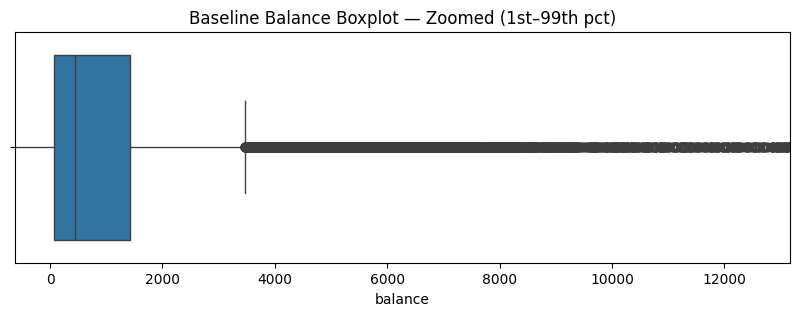

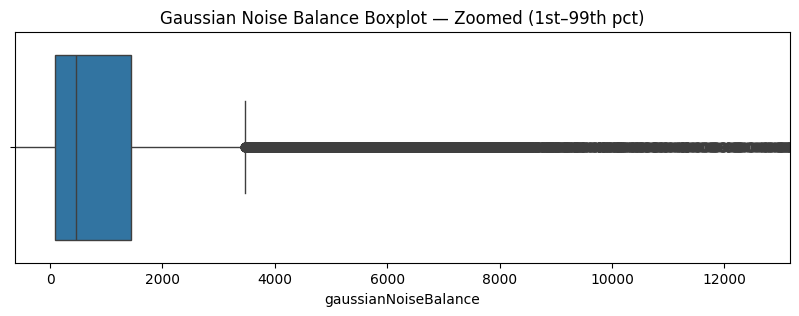

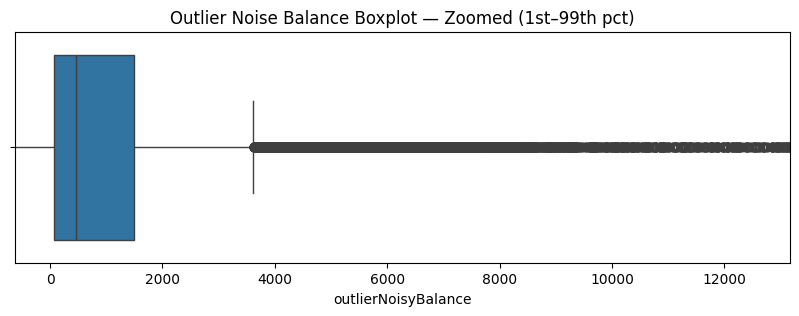

In [82]:

base = dataFrame_new['balance']
xmin, xmax = base.quantile(0.01), base.quantile(0.99)

plt.figure(figsize=(10,3))
sns.boxplot(x=base)
plt.xlim(xmin, xmax)
plt.title("Baseline Balance Boxplot — Zoomed (1st–99th pct)")
plt.xlabel("balance")
plt.show()

plt.figure(figsize=(10,3))
sns.boxplot(x=gaussian_df['gaussianNoiseBalance'])
plt.xlim(xmin, xmax)
plt.title("Gaussian Noise Balance Boxplot — Zoomed (1st–99th pct)")
plt.xlabel("gaussianNoiseBalance")
plt.show()

plt.figure(figsize=(10,3))
sns.boxplot(x=outlier_df['outlierNoisyBalance'])
plt.xlim(xmin, xmax)
plt.title("Outlier Noise Balance Boxplot — Zoomed (1st–99th pct)")
plt.xlabel("outlierNoisyBalance")
plt.show()


**Step 4.5** :-  
Noise mitigation

We will use Log transform because it does not remove outliers but it does reduce their impact by compressing the large values.

In [83]:
def shift_and_log1p(series):
    min_val = series.min()
    shift = (-min_val) if min_val < 0 else 0.0
    shifted = series + shift
    return shifted, np.log1p(shifted), shift

# Baseline
dataFrame_new['balance_shifted'], dataFrame_new['balance_log'], balance_shift = shift_and_log1p(dataFrame_new['balance'])

# Gaussian noise
gaussian_df['gaussianNoiseBalance_shifted'], gaussian_df['gaussianNoiseBalance_log'], gaussian_shift = shift_and_log1p(
    gaussian_df['gaussianNoiseBalance']
)

# Outlier noise
outlier_df['outlierNoisyBalance_shifted'], outlier_df['outlierNoisyBalance_log'], outlier_shift = shift_and_log1p(
    outlier_df['outlierNoisyBalance']
)

print(f"Shifts applied -> baseline: {balance_shift:.3f}, gaussian: {gaussian_shift:.3f}, outlier: {outlier_shift:.3f}")


Shifts applied -> baseline: 8019.000, gaussian: 8012.566, outlier: 8019.000


**Step 4.7**

Visual plots and comparisons:-

**Step 4.7.1 :-  **  
For data frame 'dataFrame_new' balance Vs Log Balance:-

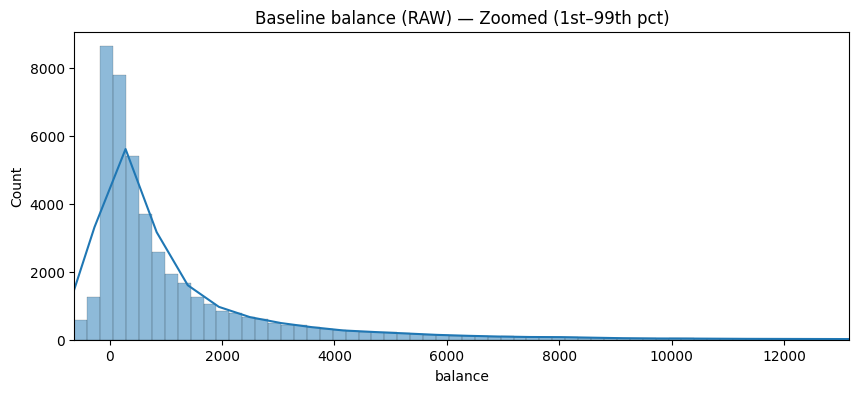

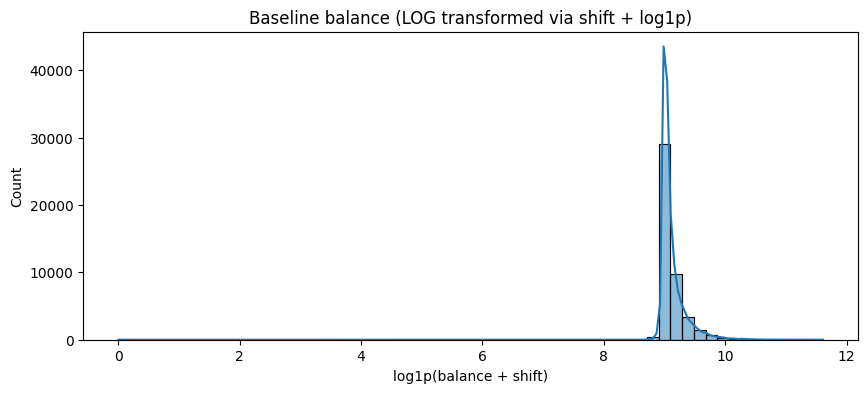

In [84]:
base = dataFrame_new['balance']
xmin, xmax = base.quantile(0.01), base.quantile(0.99)
bins = 60

plt.figure(figsize=(10,4))
sns.histplot(dataFrame_new['balance'], bins=bins, binrange=(xmin, xmax), kde=True)
plt.xlim(xmin, xmax)
plt.title("Baseline balance (RAW) — Zoomed (1st–99th pct)")
plt.xlabel("balance")
plt.show()

plt.figure(figsize=(10,4))
sns.histplot(dataFrame_new['balance_log'], bins=bins, kde=True)
plt.title("Baseline balance (LOG transformed via shift + log1p)")
plt.xlabel("log1p(balance + shift)")
plt.show()


**Step 4.7.2** :-   
Gaussian Noise before and after log transform:-

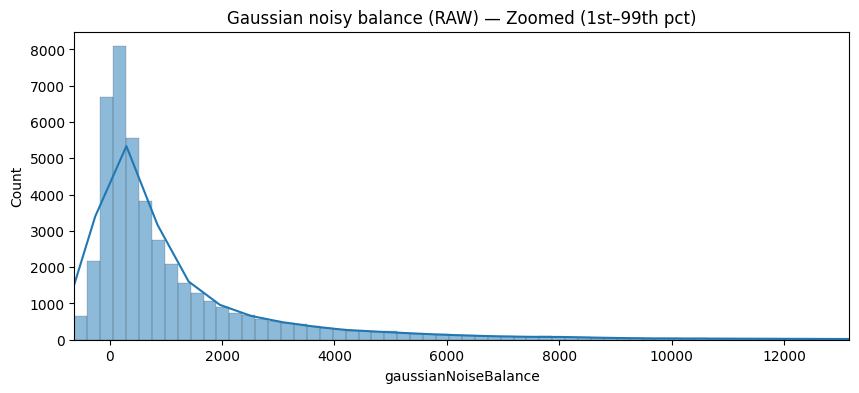

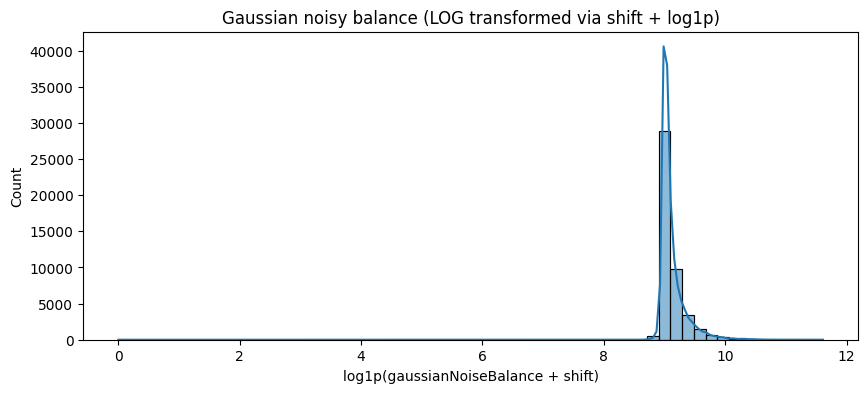

In [85]:

base = dataFrame_new['balance']
xmin, xmax = base.quantile(0.01), base.quantile(0.99)
bins = 60

plt.figure(figsize=(10,4))
sns.histplot(gaussian_df['gaussianNoiseBalance'], bins=bins, binrange=(xmin, xmax), kde=True)
plt.xlim(xmin, xmax)
plt.title("Gaussian noisy balance (RAW) — Zoomed (1st–99th pct)")
plt.xlabel("gaussianNoiseBalance")
plt.show()

plt.figure(figsize=(10,4))
sns.histplot(gaussian_df['gaussianNoiseBalance_log'], bins=bins, kde=True)
plt.title("Gaussian noisy balance (LOG transformed via shift + log1p)")
plt.xlabel("log1p(gaussianNoiseBalance + shift)")
plt.show()


**Step 4.7.3** :-

Outlier Noise before and After noise log transform:-

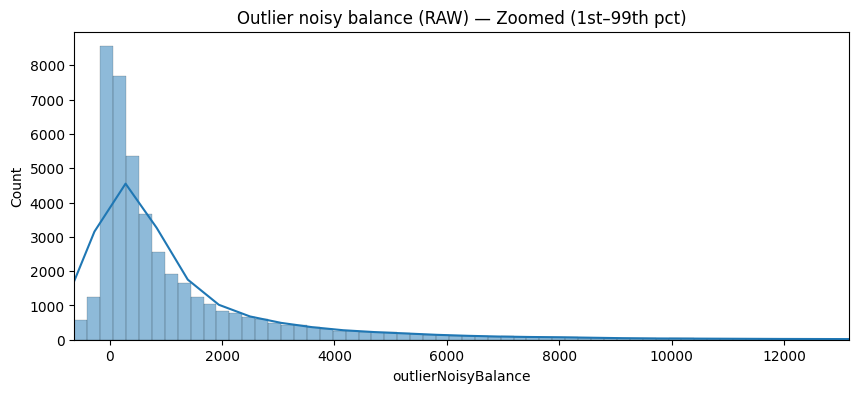

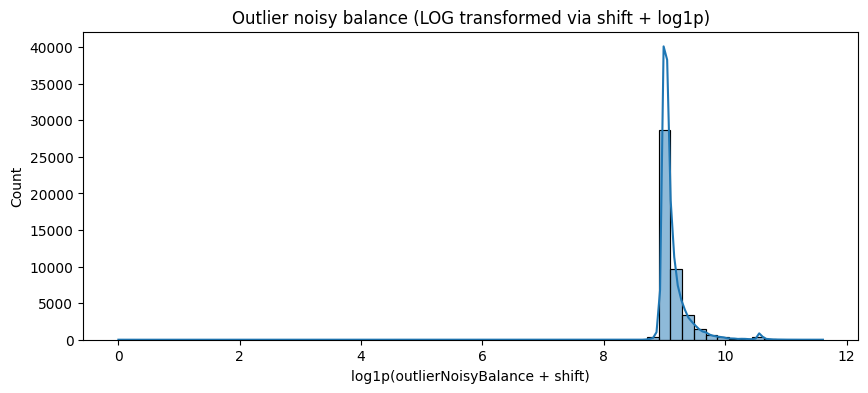

In [86]:

base = dataFrame_new['balance']
xmin, xmax = base.quantile(0.01), base.quantile(0.99)
bins = 60

plt.figure(figsize=(10,4))
sns.histplot(outlier_df['outlierNoisyBalance'], bins=bins, binrange=(xmin, xmax), kde=True)
plt.xlim(xmin, xmax)
plt.title("Outlier noisy balance (RAW) — Zoomed (1st–99th pct)")
plt.xlabel("outlierNoisyBalance")
plt.show()

plt.figure(figsize=(10,4))
sns.histplot(outlier_df['outlierNoisyBalance_log'], bins=bins, kde=True)
plt.title("Outlier noisy balance (LOG transformed via shift + log1p)")
plt.xlabel("log1p(outlierNoisyBalance + shift)")
plt.show()
